# Daisyworld: динамика модели

Построим комплексный график: число маргариток, средняя температура и
солнечная постоянная в зависимости от модельного времени.

Используется сценарий `:ramp`: с 200 по 400 шаг солнечная постоянная
растёт, с 500 по 750 шаг убывает вдвое медленнее.

## Активация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"
using Agents
using DataFrames
using CairoMakie

include(srcdir("daisyworld.jl"))

daisyworld (generic function with 1 method)

## Сбор данных

По агентам считаем число маргариток каждого вида. По модели собираем
среднюю температуру поверхности и солнечную постоянную.

In [2]:
black(a) = a.breed == :black
white(a) = a.breed == :white
adata = [(black, count), (white, count)]

temperature(model) = StatsBase.mean(model.temperature)
mdata = [temperature, :solar_luminosity]

2-element Vector{Any}:
 temperature (generic function with 1 method)
 :solar_luminosity

## Запуск модели

In [3]:
model = daisyworld(solar_luminosity = 1.0, scenario = :ramp)

agent_df, model_df = run!(model, 1000; adata = adata, mdata = mdata)
first(model_df, 5)

Row,time,temperature,solar_luminosity
,Int64,Float64,Float64
1,0,16.9135,1.0
2,1,23.4578,1.0
3,2,28.2911,1.0
4,3,30.8537,1.0
5,4,32.0085,1.0


## Построение графика

Три панели: число маргариток, температура, солнечная постоянная.

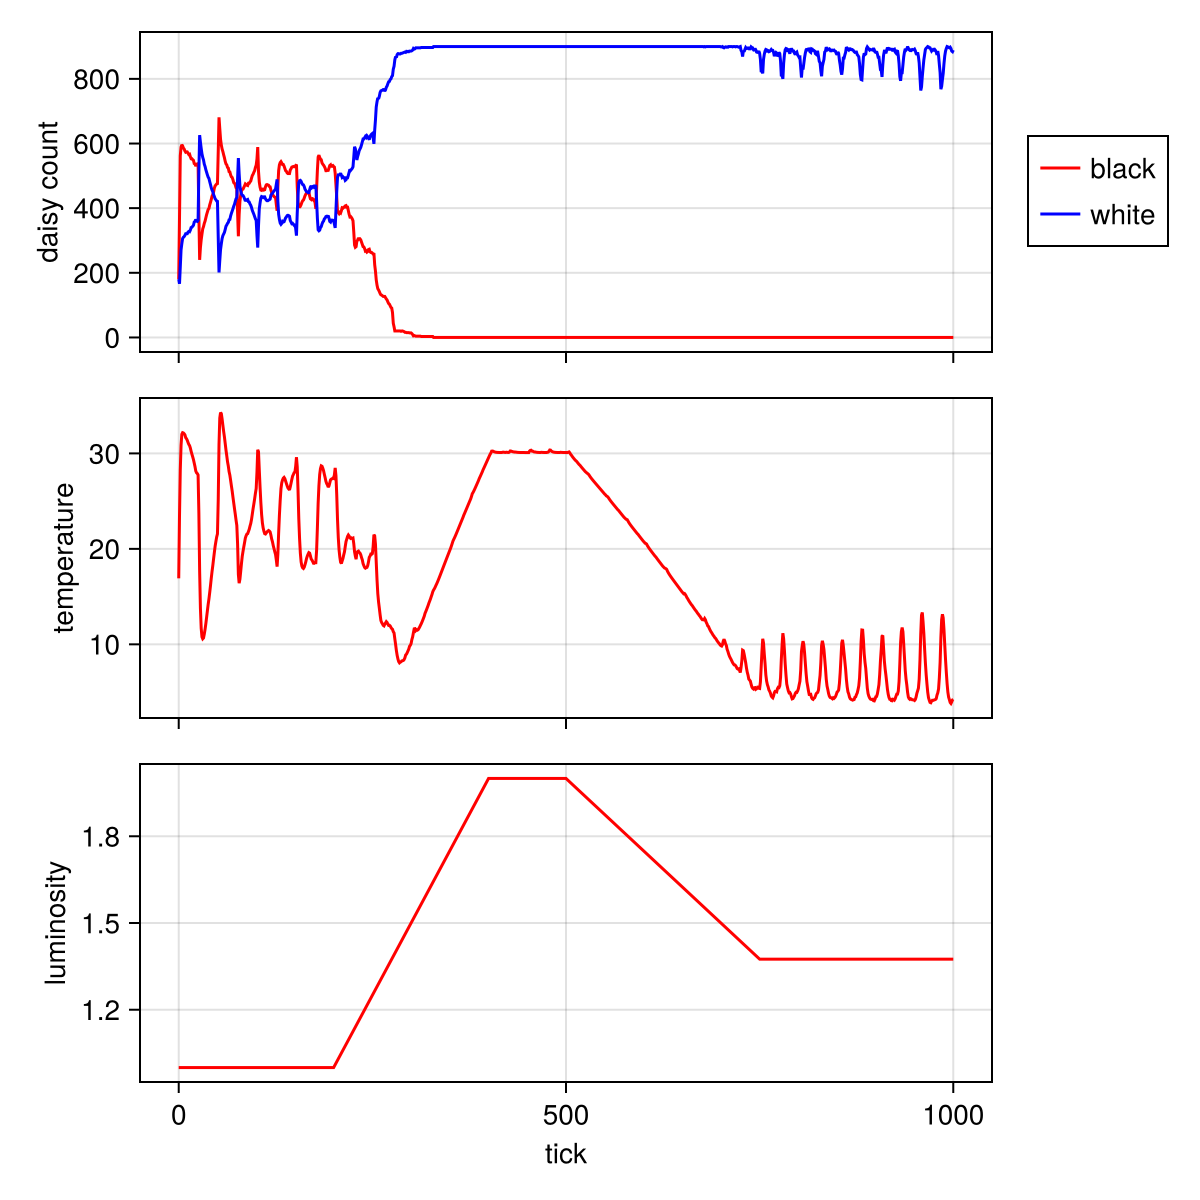

In [4]:
figure = CairoMakie.Figure(size = (600, 600));
ax1 = figure[1, 1] = Axis(figure, ylabel = "daisy count")
blackl = lines!(ax1, agent_df[!, :time], agent_df[!, :count_black], color = :red)
whitel = lines!(ax1, agent_df[!, :time], agent_df[!, :count_white], color = :blue)
figure[1, 2] = Legend(figure, [blackl, whitel], ["black", "white"])

ax2 = figure[2, 1] = Axis(figure, ylabel = "temperature")
ax3 = figure[3, 1] = Axis(figure, xlabel = "tick", ylabel = "luminosity")
lines!(ax2, model_df[!, :time], model_df[!, :temperature], color = :red)
lines!(ax3, model_df[!, :time], model_df[!, :solar_luminosity], color = :red)
for ax in (ax1, ax2); ax.xticklabelsvisible = false; end
figure

## Сохранение графика

In [5]:
save(plotsdir("daisy_luminosity.png"), figure)